# Notebook 08 — CNN com Imagens de Raio-X

## Objetivo

Este notebook cobre a **Parte Extra** do Tech Challenge: detecção de pneumonia a partir de imagens de raio-X do tórax utilizando Redes Neurais Convolucionais (CNN) com Transfer Learning.

**Step do ML Life Cycle:** Step 1 — Collect the Data (etapa 3.1)

**Dataset:** Chest X-Ray Pneumonia (Kaggle — paultimothymooney/chest-xray-pneumonia)

**O que será feito nesta seção:**
- Verificar estrutura de pastas e integridade do dataset
- Documentar a quantidade de imagens por classe e por split
- Analisar o balanceamento das classes
- Visualizar amostras representativas das imagens

In [1]:
# Bibliotecas padrão
import os
from pathlib import Path

# Manipulação de dados
import numpy as np
import pandas as pd

# Visualização
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Leitura de imagens
from PIL import Image

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


In [2]:
RANDOM_STATE  = 42
IMG_SIZE      = (224, 224)
DATA_PATH     = Path('../data/images/chest_xray')
REPORTS_PATH  = Path('../reports')
SPLITS        = ['train', 'val', 'test']
CLASSES       = ['NORMAL', 'PNEUMONIA']

REPORTS_PATH.mkdir(parents=True, exist_ok=True)

---
## 1. Verificação da Estrutura de Pastas

O dataset Chest X-Ray Pneumonia já vem pré-dividido em três splits:
- **train** — usado para treinar o modelo
- **val** — usado para monitorar o treinamento epoch a epoch
- **test** — avaliação final do modelo (usado apenas uma vez, no Step 6)

Cada split contém duas subpastas: `NORMAL` e `PNEUMONIA`.

In [5]:
print(f'Caminho RELATIVO base do dataset: {DATA_PATH}\n')

estrutura_ok = True
for split in SPLITS:
    for classe in CLASSES:
        caminho = DATA_PATH / split / classe
        existe = caminho.exists()
        status = '✓' if existe else '✗ FALTANDO'
        print(f'  {status}  {split}/{classe}')
        if not existe:
            estrutura_ok = False

print()
if estrutura_ok:
    print('Estrutura de pastas: OK — todos os diretórios encontrados.')
else:
    print('ATENÇÃO: Estrutura incompleta — verificar o download do dataset.')

Caminho RELATIVO base do dataset: ../data/images/chest_xray

  ✓  train/NORMAL
  ✓  train/PNEUMONIA
  ✓  val/NORMAL
  ✓  val/PNEUMONIA
  ✓  test/NORMAL
  ✓  test/PNEUMONIA

Estrutura de pastas: OK — todos os diretórios encontrados.


---
## 2. Contagem de Imagens por Classe e por Split

Antes de treinar qualquer modelo, é essencial entender a distribuição dos dados:
- **Quantidade total** de imagens disponíveis
- **Distribuição entre classes** (balanceamento)
- **Distribuição entre splits** (proporção treino/val/teste)

In [6]:
contagens = {}
extensoes_encontradas = set()

for split in SPLITS:
    contagens[split] = {}
    for classe in CLASSES:
        caminho = DATA_PATH / split / classe
        arquivos = list(caminho.glob('*'))
        imagens  = [f for f in arquivos if f.suffix.lower() in ('.jpeg', '.jpg', '.png')]
        extensoes_encontradas.update(f.suffix.lower() for f in imagens)
        contagens[split][classe] = len(imagens)

# Montar DataFrame para visualização
registros = []
for split in SPLITS:
    for classe in CLASSES:
        registros.append({'Split': split, 'Classe': classe, 'Quantidade': contagens[split][classe]})

df_contagens = pd.DataFrame(registros)

# Totais por split
totais_split = df_contagens.groupby('Split')['Quantidade'].sum().reset_index()
totais_split.columns = ['Split', 'Total']

# Pivot para exibição
df_pivot = df_contagens.pivot(index='Split', columns='Classe', values='Quantidade').reindex(SPLITS)
df_pivot['TOTAL'] = df_pivot.sum(axis=1)
df_pivot.loc['TOTAL'] = df_pivot.sum()

print('Contagem de imagens por split e classe:')
print()
print(df_pivot.to_string())
print()
print(f'Extensões encontradas: {extensoes_encontradas}')

Contagem de imagens por split e classe:

Classe  NORMAL  PNEUMONIA  TOTAL
Split                           
train     1341       3875   5216
val          8          8     16
test       234        390    624
TOTAL     1583       4273   5856

Extensões encontradas: {'.jpeg'}


### Análise do Balanceamento

In [7]:
# Proporção por classe dentro de cada split
df_prop = df_contagens.copy()
total_por_split = df_contagens.groupby('Split')['Quantidade'].transform('sum')
df_prop['Proporção (%)'] = (df_prop['Quantidade'] / total_por_split * 100).round(1)

df_prop_pivot = df_prop.pivot(index='Split', columns='Classe', values='Proporção (%)').reindex(SPLITS)
df_prop_pivot.columns = [f'{c} (%)' for c in df_prop_pivot.columns]

print('Proporção de cada classe por split (%):')
print()
print(df_prop_pivot.to_string())

# Razão de desbalanceamento no treino
n_normal    = contagens['train']['NORMAL']
n_pneumonia = contagens['train']['PNEUMONIA']
razao = n_pneumonia / n_normal
print()
print(f'Razão PNEUMONIA/NORMAL no treino: {razao:.2f}x')

Proporção de cada classe por split (%):

       NORMAL (%)  PNEUMONIA (%)
Split                           
train        25.7           74.3
val          50.0           50.0
test         37.5           62.5

Razão PNEUMONIA/NORMAL no treino: 2.89x


### Gráfico: Distribuição das Classes por Split

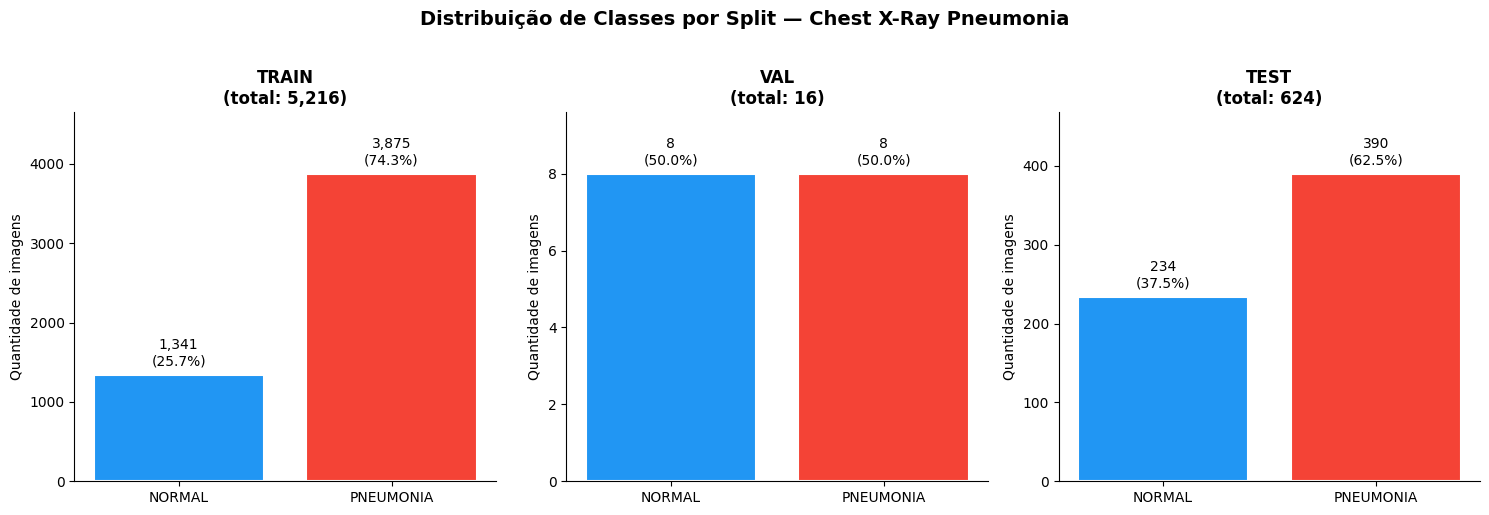

Gráfico salvo em reports/cnn_distribuicao_classes.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribuição de Classes por Split — Chest X-Ray Pneumonia', fontsize=14, fontweight='bold', y=1.02)

cores = {'NORMAL': '#2196F3', 'PNEUMONIA': '#F44336'}

for ax, split in zip(axes, SPLITS):
    valores  = [contagens[split][c] for c in CLASSES]
    barras   = ax.bar(CLASSES, valores, color=[cores[c] for c in CLASSES], edgecolor='white', linewidth=1.5)
    total    = sum(valores)
    ax.set_title(f'{split.upper()}\n(total: {total:,})', fontsize=12, fontweight='bold')
    ax.set_ylabel('Quantidade de imagens')
    ax.set_ylim(0, max(valores) * 1.2)
    for barra, valor in zip(barras, valores):
        pct = valor / total * 100
        ax.text(barra.get_x() + barra.get_width() / 2, barra.get_height() + max(valores) * 0.02,
                f'{valor:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'cnn_distribuicao_classes.png', bbox_inches='tight', dpi=150)
plt.show()
print('Gráfico salvo em reports/cnn_distribuicao_classes.png')

**Interpretação:**

O dataset apresenta **desbalanceamento significativo no split de treino**: há aproximadamente **2,9x mais imagens de PNEUMONIA do que NORMAL** (3.875 vs 1.341). Este padrão é típico em datasets médicos, onde casos patológicos tendem a ser mais representados.

O split de **validação é muito pequeno** (apenas 16 imagens — 8 por classe), o que é insuficiente para uma avaliação confiável durante o treinamento. Para contornar isso, utilizaremos **validation_split** a partir do conjunto de treino ao invés do diretório `val/` original.

**Impacto no treinamento da CNN:**
- O desbalanceamento será tratado com **class_weight** no `model.fit()`
- A métrica principal será **Recall** (sensibilidade), pois um Falso Negativo — classificar pneumonia como normal — é clinicamente mais grave que um Falso Positivo
- Data augmentation será aplicado **apenas no treino** para aumentar a diversidade das amostras NORMAL e reduzir o overfitting

---
## 3. Análise das Dimensões das Imagens

As imagens de raio-X possuem dimensões variadas. Para alimentar a CNN, todas precisarão ser redimensionadas para um tamanho fixo (`IMG_SIZE`). Vamos verificar a distribuição de tamanhos para confirmar a escolha de `224×224` pixels.

In [9]:
# Amostrar 200 imagens do treino para análise de dimensões (evitar leitura de 5k+ imagens)
np.random.seed(RANDOM_STATE)
AMOSTRAS_DIMENSAO = 200

larguras, alturas = [], []

for classe in CLASSES:
    caminho_classe = DATA_PATH / 'train' / classe
    arquivos = list(caminho_classe.glob('*.jpeg')) + list(caminho_classe.glob('*.jpg'))
    n_amostras = min(AMOSTRAS_DIMENSAO // len(CLASSES), len(arquivos))
    selecionados = np.random.choice(arquivos, n_amostras, replace=False)
    for caminho_img in selecionados:
        with Image.open(caminho_img) as img:
            w, h = img.size
            larguras.append(w)
            alturas.append(h)

print(f'Amostra analisada: {len(larguras)} imagens do split train')
print()
print(f'Largura  — min: {min(larguras):5d}px | max: {max(larguras):5d}px | mediana: {int(np.median(larguras)):5d}px')
print(f'Altura   — min: {min(alturas):5d}px | max: {max(alturas):5d}px | mediana: {int(np.median(alturas)):5d}px')
print()
print(f'Tamanho alvo para a CNN: {IMG_SIZE[0]}×{IMG_SIZE[1]} px')

Amostra analisada: 200 imagens do split train

Largura  — min:   438px | max:  2721px | mediana:  1416px
Altura   — min:   157px | max:  2438px | mediana:  1054px

Tamanho alvo para a CNN: 224×224 px


---
## 4. Visualização de Amostras das Imagens

Antes de treinar qualquer modelo, é boa prática **olhar para os dados**. Vamos visualizar amostras representativas de cada classe para entender as características visuais que a CNN precisará aprender a distinguir.

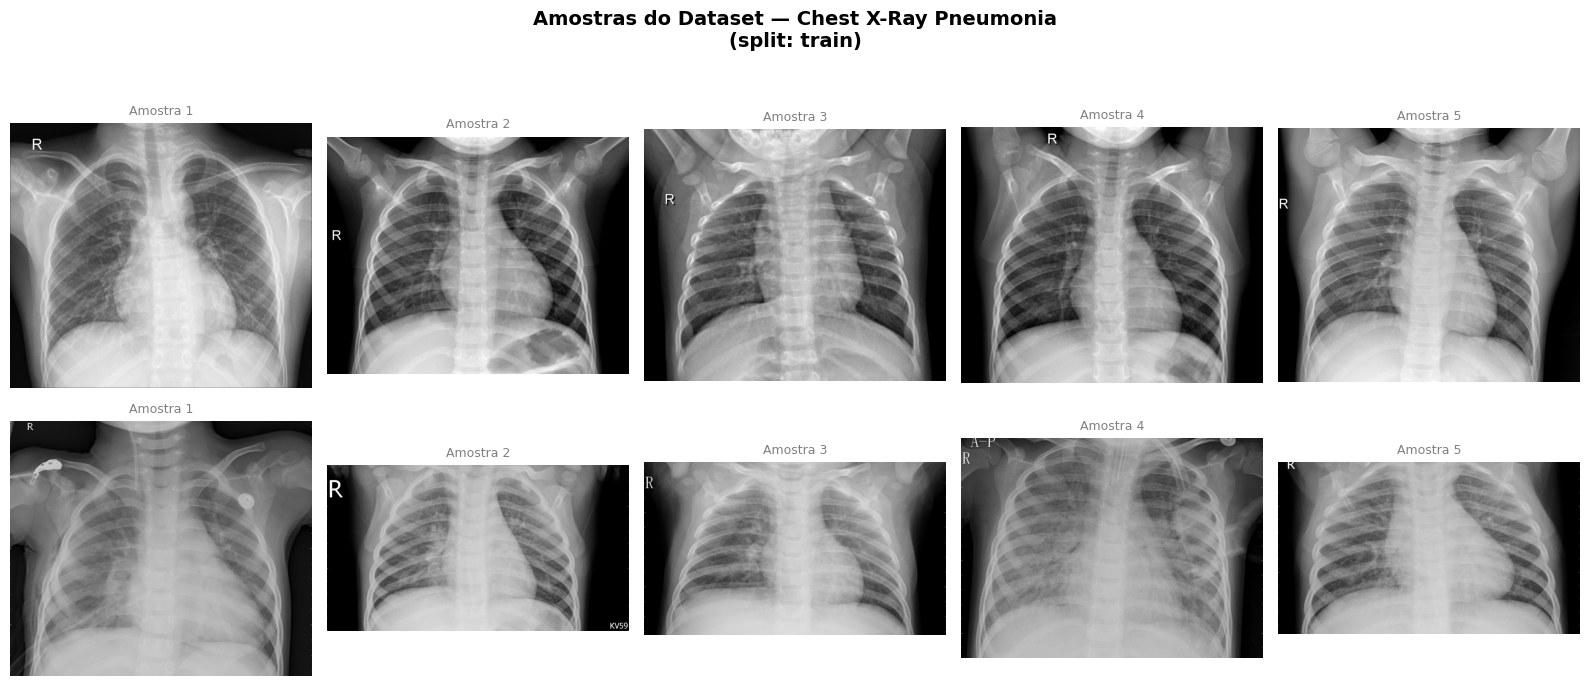

Gráfico salvo em reports/cnn_amostras_dataset.png


In [10]:
np.random.seed(RANDOM_STATE)
N_AMOSTRAS = 5  # amostras por classe

fig, axes = plt.subplots(len(CLASSES), N_AMOSTRAS, figsize=(16, 7))
fig.suptitle('Amostras do Dataset — Chest X-Ray Pneumonia\n(split: train)', 
             fontsize=14, fontweight='bold', y=1.02)

titulos_classe = {
    'NORMAL':    ('NORMAL\n(Pulmão Saudável)', '#2196F3'),
    'PNEUMONIA': ('PNEUMONIA\n(Pulmão Infectado)', '#F44336')
}

for row_idx, classe in enumerate(CLASSES):
    caminho_classe = DATA_PATH / 'train' / classe
    arquivos = list(caminho_classe.glob('*.jpeg')) + list(caminho_classe.glob('*.jpg'))
    selecionados = np.random.choice(arquivos, N_AMOSTRAS, replace=False)
    titulo_cls, cor_cls = titulos_classe[classe]
    
    for col_idx, caminho_img in enumerate(selecionados):
        ax = axes[row_idx, col_idx]
        with Image.open(caminho_img) as img:
            ax.imshow(img, cmap='gray')
        ax.axis('off')
        if col_idx == 0:
            ax.set_ylabel(titulo_cls, fontsize=11, fontweight='bold', color=cor_cls,
                          rotation=0, labelpad=120, va='center')
        ax.set_title(f'Amostra {col_idx + 1}', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'cnn_amostras_dataset.png', bbox_inches='tight', dpi=150)
plt.show()
print('Gráfico salvo em reports/cnn_amostras_dataset.png')

**O que observar nas imagens:**

- **NORMAL:** pulmões com campos pulmonares claros (regiões escuras no raio-X), sem opacidades
- **PNEUMONIA:** presença de **infiltrados** (regiões mais claras/brancas) nos pulmões, indicando acúmulo de líquido ou pus nos alvéolos pulmonares

Estas diferenças visuais são o sinal que a CNN aprenderá a identificar. O Transfer Learning (pesos pré-treinados de modelos como MobileNetV2 ou EfficientNet) acelerará esse aprendizado, pois os filtros convolucionais iniciais detectam bordas e texturas que são universais entre domínios de imagem.

---
## 5. Verificação de Integridade das Imagens

Verificar se há imagens corrompidas que possam causar erros durante o treinamento.

In [11]:
corrompidas = []
total_verificadas = 0

# Verificar todos os arquivos de todos os splits
for split in SPLITS:
    for classe in CLASSES:
        caminho_classe = DATA_PATH / split / classe
        arquivos = list(caminho_classe.glob('*.jpeg')) + list(caminho_classe.glob('*.jpg')) + list(caminho_classe.glob('*.png'))
        for caminho_img in arquivos:
            total_verificadas += 1
            try:
                with Image.open(caminho_img) as img:
                    img.verify()  # verifica integridade sem carregar pixels
            except Exception as e:
                corrompidas.append({'arquivo': str(caminho_img), 'erro': str(e)})

print(f'Total de imagens verificadas: {total_verificadas:,}')
if corrompidas:
    print(f'Imagens corrompidas encontradas: {len(corrompidas)}')
    for item in corrompidas:
        print(f"  - {item['arquivo']}: {item['erro']}")
else:
    print('Nenhuma imagem corrompida encontrada. Dataset íntegro.')

Total de imagens verificadas: 5,856
Nenhuma imagem corrompida encontrada. Dataset íntegro.


---
## Resumo — Step 1: Collect the Data (Imagens)

### O que foi coletado e verificado

| Item | Detalhe |
|---|---|
| **Fonte** | Kaggle — paultimothymooney/chest-xray-pneumonia |
| **Licença** | CC BY 4.0 (Kermany, Zhang, Goldbaum — 2018) |
| **Total de imagens** | 5.856 |
| **Classes** | NORMAL, PNEUMONIA |
| **Formato** | JPEG / grayscale |
| **Estrutura** | Pré-dividido em train / val / test |
| **Split de treino** | 5.216 imagens (1.341 NORMAL + 3.875 PNEUMONIA) |
| **Split de teste** | 624 imagens (234 NORMAL + 390 PNEUMONIA) |
| **Split de val** | 16 imagens (8+8) — muito pequeno, será substituído |
| **Desbalanceamento no treino** | ~2,9x mais PNEUMONIA que NORMAL |
| **Tamanho alvo** | 224×224 px (compatível com MobileNetV2 / EfficientNetB0) |

### Decisões tomadas para as próximas etapas

1. **class_weight** será calculado e passado ao `model.fit()` para compensar o desbalanceamento
2. **validation_split** será extraído do treino (ex: 20%) em vez de usar o diretório `val/` original (muito pequeno)
3. **Data Augmentation** aplicado exclusivamente ao treino (rotação, zoom, flip horizontal)
4. **Métrica principal:** Recall — minimizar Falsos Negativos é crítico no contexto diagnóstico
5. **Transfer Learning:** MobileNetV2 ou EfficientNetB0 pré-treinado em ImageNet

## Próximo passo

Continuar no mesmo notebook **08_cnn_imagens.ipynb** com o Step 2 (Prepare / Data Augmentation) seguido de Steps 3–6 (Choose → Train → Tune → Evaluate), conforme etapa **3.2** da spec.

---
## Etapa 3.2 — CNN com Transfer Learning

**Steps do ML Life Cycle cobertos nesta seção:**

| Step | Descrição | O que fazemos |
|---|---|---|
| **Step 2** | Prepare the Data | Data augmentation + normalização |
| **Step 3** | Choose a Model | Transfer Learning com MobileNetV2 |
| **Step 4** | Train the Model | Treinamento com base congelada |
| **Step 5** | Parameter Tuning | Fine-tuning das últimas camadas |
| **Step 6** | Evaluation & Testing | Avaliação no conjunto de teste |

> **Nota técnica:** Este notebook utiliza **Keras 3 + PyTorch backend** (em vez de TensorFlow),
> pois o ambiente usa Python 3.14, ainda não suportado pelo TensorFlow.
> A API do Keras 3 é idêntica à do tf.keras para os recursos utilizados aqui.

In [ ]:
# IMPORTANTE: definir backend ANTES de importar keras
import os
os.environ['KERAS_BACKEND'] = 'torch'

# Deep Learning
import keras
import numpy as np

# Visualização e métricas
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Utilitários
from pathlib import Path

print(f'Keras: {keras.__version__}')
print(f'Backend: {keras.backend.backend()}')

In [ ]:
IMG_SIZE      = (224, 224)
BATCH_SIZE    = 32
EPOCHS_FASE1  = 20
EPOCHS_FASE2  = 10
RANDOM_STATE  = 42
DATA_PATH     = Path('../data/images/chest_xray')
MODEL_PATH    = Path('../models')
REPORTS_PATH  = Path('../reports')

MODEL_PATH.mkdir(parents=True, exist_ok=True)
REPORTS_PATH.mkdir(parents=True, exist_ok=True)

---
## Step 2 — Prepare: Data Augmentation

**Por que aumentar os dados?**
O split de treino tem apenas 1.341 imagens NORMAL — um número modesto para treinar uma CNN
do zero. O *data augmentation* cria variações sintéticas das imagens existentes durante
o treino, aumentando artificialmente a diversidade e reduzindo o overfitting.

**Transformações escolhidas (apenas no treino):**
- `RandomFlip(horizontal)` — flip horizontal é realista em raio-X de tórax
- `RandomRotation(0.1)` — pequena rotação (±10%) simula variações de posicionamento do paciente
- `RandomZoom(0.1)` — zoom leve simula variações de distância entre paciente e equipamento

**Importante:** augmentation é aplicado **exclusivamente no treino** — nunca na validação ou teste.

In [ ]:
# Camada de augmentation (aplicada apenas durante model.fit — training=True)
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip('horizontal'),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
], name='data_augmentation')

print('Pipeline de data augmentation criado.')
print('Transformações: RandomFlip + RandomRotation(10%) + RandomZoom(10%)')

### Carregamento dos Dados com `image_dataset_from_directory`

O split de validação original tem apenas 16 imagens (8 por classe), insuficiente para
monitorar o treinamento com confiança. Por isso, extraímos 20% do conjunto de treino
como validação, garantindo balanceamento e representatividade.

In [ ]:
# Treino: 80% das imagens do diretório train/, com augmentation (via camada no modelo)
train_ds = keras.utils.image_dataset_from_directory(
    DATA_PATH / 'train',
    validation_split=0.20,
    subset='training',
    seed=RANDOM_STATE,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
)

# Validação: 20% das imagens do diretório train/, sem augmentation
val_ds = keras.utils.image_dataset_from_directory(
    DATA_PATH / 'train',
    validation_split=0.20,
    subset='validation',
    seed=RANDOM_STATE,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
)

# Teste: diretório test/ completo, shuffle=False para alinhar labels com predições
test_ds = keras.utils.image_dataset_from_directory(
    DATA_PATH / 'test',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False,
)

CLASSES_NOMES = train_ds.class_names  # ['NORMAL', 'PNEUMONIA'] — ordem alfabética
print(f'Classes: {CLASSES_NOMES}  →  NORMAL=0, PNEUMONIA=1')
print(f'Batches de treino  : {len(train_ds):4d} ({len(train_ds) * BATCH_SIZE:,} imagens aprox.)')
print(f'Batches de validação: {len(val_ds):4d} ({len(val_ds) * BATCH_SIZE:,} imagens aprox.)')
print(f'Batches de teste   : {len(test_ds):4d} ({len(test_ds) * BATCH_SIZE:,} imagens aprox.)')

In [ ]:
# Calcular class_weight para compensar o desbalanceamento no treino
# Contagens reais (do Step 1): NORMAL=1.341, PNEUMONIA=3.875
n_normal    = len(list((DATA_PATH / 'train' / 'NORMAL').glob('*.jpeg')))
n_pneumonia = len(list((DATA_PATH / 'train' / 'PNEUMONIA').glob('*.jpeg')))
total_treino = n_normal + n_pneumonia

# Fórmula: peso = total / (n_classes * n_amostras_da_classe)
# Classes: NORMAL=0, PNEUMONIA=1
class_weight = {
    0: total_treino / (2 * n_normal),
    1: total_treino / (2 * n_pneumonia),
}

print('Pesos por classe para compensar o desbalanceamento:')
print(f'  NORMAL    (classe 0): {n_normal:,} imagens → peso: {class_weight[0]:.3f}')
print(f'  PNEUMONIA (classe 1): {n_pneumonia:,} imagens → peso: {class_weight[1]:.3f}')
print()
print('Interpretação: imagens NORMAL terão peso ~{:.1f}x maior que PNEUMONIA'.format(
    class_weight[0] / class_weight[1]))

**Interpretação:** O modelo receberá penalização maior ao errar imagens NORMAL, compensando
o fato de que há 2,9x mais imagens de PNEUMONIA no treino. Sem essa correção, o modelo
tenderia a classificar tudo como PNEUMONIA e ainda atingir alta acurácia (74%).

---
## Step 3 — Choose a Model: Transfer Learning com MobileNetV2

**Por que Transfer Learning?**
Treinar uma CNN do zero para imagens médicas exigiria centenas de milhares de amostras
anotadas. Com Transfer Learning, aproveitamos os pesos do **MobileNetV2**, treinado em
1,4 milhão de imagens do ImageNet — os filtros que detectam bordas, texturas e padrões
genéricos são reutilizados e apenas as camadas de classificação final são treinadas do zero.

**Por que MobileNetV2?**

| Critério | MobileNetV2 |
|---|---|
| Tamanho | Leve (~14MB) — adequado para o dataset pequeno |
| Performance | ~72% top-1 no ImageNet — bom equilíbrio |
| Compatibilidade | Disponível em `keras.applications` — pronto para uso |
| Entrada | 224×224×3 — compatível com nosso `IMG_SIZE` |

**Arquitetura final:**
1. `data_augmentation` — transformações aleatórias (só no treino)
2. `Rescaling` — normaliza pixels de [0, 255] para [-1, 1] (range esperado pelo MobileNetV2)
3. `MobileNetV2` (congelado) — 154 camadas pré-treinadas, sem atualização de gradiente
4. `GlobalAveragePooling2D` — reduz o feature map para 1D
5. `Dense(128, relu)` — camada de classificação intermediária
6. `Dropout(0.3)` — regularização: desliga 30% dos neurônios no treino
7. `Dense(1, sigmoid)` — saída: probabilidade de PNEUMONIA (0=Normal, 1=Pneumonia)

In [ ]:
# Base model: MobileNetV2 pré-treinado no ImageNet, sem a camada de classificação
base_model = keras.applications.MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Fase 1: congelar todos os pesos do base model

# Arquitetura completa usando Functional API
inputs = keras.Input(shape=(*IMG_SIZE, 3))

# Step 2: augmentation (aplicado apenas em training=True pelo Keras)
x = data_augmentation(inputs)

# Normalizar para o range esperado pelo MobileNetV2: [-1, 1]
x = keras.layers.Rescaling(scale=1.0 / 127.5, offset=-1)(x)

# Base model com training=False para manter BatchNorm em modo inferência
x = base_model(x, training=False)

# Cabeça de classificação
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(128, activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)
outputs = keras.layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs, name='cnn_transfer_learning')
model.summary()

**Análise da arquitetura:**
- O modelo tem ~2,3M de parâmetros no total
- Na Fase 1, apenas os parâmetros da "cabeça" (~131K) são treináveis
- O MobileNetV2 funciona como um **extrator de features** estático nesta fase
- Na Fase 2 (fine-tuning), as últimas camadas do base model também serão atualizadas

---
## Step 4 — Train the Model: Fase 1 — Base Congelada

**Estratégia:** Treinar primeiro apenas a cabeça de classificação (Dense + Dropout) com
o MobileNetV2 completamente congelado. Isso evita que os pesos pré-treinados sejam
destruídos por gradientes grandes nas primeiras epochs.

**Callbacks utilizados:**
- `EarlyStopping`: para o treino quando o `val_recall` não melhora por 5 epochs consecutivas
  e restaura os melhores pesos automaticamente
- `ModelCheckpoint`: salva apenas o modelo com melhor `val_recall` em disco

**Métrica monitorada:** `val_recall` — em diagnóstico médico, maximizar Recall
(sensibilidade) é prioritário: um Falso Negativo (dizer "Normal" para um paciente com
pneumonia) é clinicamente mais grave que um Falso Positivo.

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Recall(name='recall'),
        keras.metrics.Precision(name='precision'),
    ]
)

callbacks_fase1 = [
    keras.callbacks.EarlyStopping(
        monitor='val_recall',
        mode='max',
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(MODEL_PATH / 'cnn_melhor.keras'),
        monitor='val_recall',
        mode='max',
        save_best_only=True,
        verbose=1,
    ),
]

print('=== FASE 1: Treinamento com base congelada ===')
trainable_count = sum(int(p.numpy().size) for p in model.trainable_weights)
print(f'Parâmetros treináveis (Fase 1): {trainable_count:,}')
print()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FASE1,
    class_weight=class_weight,
    callbacks=callbacks_fase1,
    verbose=1,
)

### Curvas de Aprendizado — Fase 1

As curvas mostram como a `loss` e as métricas evoluem ao longo das epochs para os
conjuntos de treino e validação. Sinais importantes a observar:
- **Overfitting:** treino melhora mas validação piora ou estagna
- **Underfitting:** ambas melhoram pouco (modelo insuficientemente complexo)
- **Bom ajuste:** ambas melhoram juntas e convergem

In [ ]:
def plot_curvas(history_obj, titulo_sufixo='', save_name='cnn_curvas'):
    hist = history_obj.history
    epochs = range(1, len(hist['loss']) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Curvas de Aprendizado — {titulo_sufixo}', fontsize=14, fontweight='bold')

    pares = [
        ('loss',      'val_loss',      'Loss (Binary Cross-Entropy)', '#2196F3', '#F44336'),
        ('accuracy',  'val_accuracy',  'Acurácia',                    '#4CAF50', '#FF9800'),
        ('recall',    'val_recall',    'Recall (Sensibilidade)',       '#9C27B0', '#E91E63'),
    ]

    for ax, (tr_key, val_key, ylabel, c_tr, c_val) in zip(axes, pares):
        ax.plot(epochs, hist[tr_key],  color=c_tr,  lw=2, label='Treino')
        ax.plot(epochs, hist[val_key], color=c_val, lw=2, label='Validação', linestyle='--')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.legend()
        ax.grid(alpha=0.3)
        ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(REPORTS_PATH / f'{save_name}.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Gráfico salvo em reports/{save_name}.png')


plot_curvas(history, titulo_sufixo='Fase 1 (Base Congelada)', save_name='cnn_curvas_fase1')

In [ ]:
# Resumo das métricas da melhor epoch (fase 1)
best_epoch = history.history['val_recall'].index(max(history.history['val_recall'])) + 1
print(f'Melhor epoch: {best_epoch} / {len(history.history["loss"])}')
print()
print('Métricas na melhor epoch (validação):')
for metrica in ['val_loss', 'val_accuracy', 'val_recall', 'val_precision']:
    nome_fmt = metrica.replace('val_', '').replace('_', ' ').title()
    valor = history.history[metrica][best_epoch - 1]
    print(f'  {nome_fmt:20s}: {valor:.4f}')

**O que esperar nesta fase:**
- O Recall no treino deve subir rapidamente nas primeiras epochs (a cabeça aprende depressa)
- A validação pode ser ruidosa nas primeiras epochs — o EarlyStopping filtra isso
- Se `val_recall` estiver muito abaixo do treino, há overfitting → o Dropout e o class_weight
  ajudam a mitigar

---
## Step 5 — Parameter Tuning: Fine-Tuning

**O que é Fine-Tuning?**
Na Fase 1, usamos o MobileNetV2 como extrator fixo de features. No fine-tuning,
descongelamos as **últimas 20 camadas** do base model e retreinamos com um
`learning_rate` 100x menor (1e-5 vs 1e-3 padrão).

**Por que apenas as últimas camadas?**
- As primeiras camadas aprendem features genéricas (bordas, texturas) → manter congeladas
- As últimas camadas aprendem features de alto nível (formas, objetos) → ajustar para raio-X

**Por que learning_rate muito menor?**
Se o `lr` for grande, os gradientes destróem os pesos cuidadosamente pré-treinados.
Um `lr=1e-5` faz ajustes sutis, preservando o conhecimento já aprendido.

In [ ]:
# Descongelar as últimas 20 camadas do base model
base_model.trainable = True
n_layers = len(base_model.layers)
n_descongeladas = 20

for layer in base_model.layers[: n_layers - n_descongeladas]:
    layer.trainable = False

# Contar parâmetros treináveis agora
n_treinavel  = sum(int(p.numpy().size) for p in model.trainable_weights)
n_total      = sum(int(p.numpy().size) for p in model.weights)
print(f'Camadas do base_model: {n_layers}')
print(f'Descongeladas (últimas {n_descongeladas}): {sum(1 for l in base_model.layers if l.trainable)}')
print(f'Parâmetros treináveis: {n_treinavel:,} / {n_total:,} ({n_treinavel/n_total*100:.1f}%)')

In [ ]:
# Recompilar com learning_rate muito menor para preservar os pesos pré-treinados
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Recall(name='recall'),
        keras.metrics.Precision(name='precision'),
    ]
)

callbacks_fase2 = [
    keras.callbacks.EarlyStopping(
        monitor='val_recall',
        mode='max',
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(MODEL_PATH / 'cnn_finetuned.keras'),
        monitor='val_recall',
        mode='max',
        save_best_only=True,
        verbose=1,
    ),
]

print('=== FASE 2: Fine-Tuning (últimas camadas descongeladas) ===')
print()

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FASE2,
    class_weight=class_weight,
    callbacks=callbacks_fase2,
    verbose=1,
)

In [ ]:
plot_curvas(history_ft, titulo_sufixo='Fase 2 (Fine-Tuning)', save_name='cnn_curvas_fase2')

In [ ]:
# Comparação: Fase 1 vs Fase 2 (métricas de validação)
best_ep_ft = history_ft.history['val_recall'].index(max(history_ft.history['val_recall'])) + 1

metricas = ['val_accuracy', 'val_recall', 'val_precision']
print(f'{"Métrica":<25} {"Fase 1 (melhor)":>18} {"Fase 2 (melhor)":>18} {"Delta":>10}')
print('-' * 75)
for m in metricas:
    v1 = max(history.history[m])
    v2 = max(history_ft.history[m])
    delta = v2 - v1
    sinal = '+' if delta >= 0 else ''
    print(f'  {m.replace("val_", "").title():<23} {v1:>18.4f} {v2:>18.4f} {sinal}{delta:>9.4f}')

**O que esperar no fine-tuning:**
- O ganho costuma ser menor que na Fase 1 (a cabeça já aprendeu o essencial)
- Se `val_recall` não melhorar, o fine-tuning será interrompido pelo EarlyStopping(patience=3)
- O modelo fine-tuned `cnn_finetuned.keras` é o modelo final para avaliação

---
## Step 6 — Evaluation & Testing

**Regra fundamental:** O conjunto de teste é usado **apenas uma vez**, aqui.
Nenhum hiperparâmetro foi escolhido com base nele. Esta avaliação representa a
performance real esperada em dados novos, não vistos durante o desenvolvimento.

**Modelo avaliado:** `cnn_finetuned.keras` — melhor checkpoint da Fase 2 por `val_recall`.

In [ ]:
# Carregar o melhor modelo fine-tuned (salvo pelo ModelCheckpoint)
model_final = keras.models.load_model(str(MODEL_PATH / 'cnn_finetuned.keras'))
print('Modelo carregado:', MODEL_PATH / 'cnn_finetuned.keras')
print()

# Predições no conjunto de teste
# test_ds tem shuffle=False → labels e predições estão alinhados
y_pred_prob = model_final.predict(test_ds, verbose=1)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Labels reais
y_true = np.concatenate([labels for _, labels in test_ds], axis=0).astype(int).flatten()

print(f'\nTotal de imagens no teste: {len(y_true)}')
print(f'  NORMAL (0):    {(y_true == 0).sum()}')
print(f'  PNEUMONIA (1): {(y_true == 1).sum()}')

In [ ]:
# Relatório de classificação
print('=' * 60)
print('AVALIAÇÃO FINAL — CNN Fine-tuned — Conjunto de TESTE')
print('=' * 60)
print()
print(classification_report(
    y_true, y_pred,
    target_names=['Normal', 'Pneumonia'],
    digits=4
))

**Métricas relevantes no contexto médico:**
- **Recall (Sensibilidade) — PNEUMONIA:** Percentual de pacientes com pneumonia
  corretamente identificados. Esta é a métrica mais crítica: minimizar Falsos Negativos.
- **Precision — PNEUMONIA:** Percentual das alertas positivas que são realmente pneumonia.
  Falsos Positivos geram exames desnecessários, mas são clinicamente menos graves.
- **F1-Score:** Média harmônica de Recall e Precision — síntese útil quando ambas importam.

In [ ]:
# Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Normal (pred)', 'Pneumonia (pred)'],
    yticklabels=['Normal (real)', 'Pneumonia (real)'],
    ax=ax,
    annot_kws={'size': 14}
)

# Destacar células críticas
ax.set_title('Matriz de Confusão — CNN Fine-tuned\n(conjunto de teste)', fontsize=13, fontweight='bold')
ax.set_ylabel('Classe Real', fontsize=11)
ax.set_xlabel('Classe Predita', fontsize=11)

# Anotar os quadrantes
tn, fp, fn, tp = cm.ravel()
ax.text(0.5, -0.15, f'TN={tn} | FP={fp} | FN={fn} | TP={tp}',
        transform=ax.transAxes, ha='center', fontsize=10, color='gray')

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'cnn_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print('Gráfico salvo em reports/cnn_confusion_matrix.png')
print()
print(f'  Falsos Negativos (FN): {fn} — pacientes com pneumonia classificados como Normal')
print(f'  Falsos Positivos (FP): {fp} — pacientes normais classificados como Pneumonia')

In [ ]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob.flatten())
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#F44336', lw=2.5, label=f'CNN Fine-tuned (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Classificador Aleatório (AUC = 0.500)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#F44336')

# Ponto de operação atual (threshold=0.5)
thresh_idx = (np.abs(thresholds - 0.5)).argmin()
ax.scatter(fpr[thresh_idx], tpr[thresh_idx], color='black', zorder=5, s=80,
           label=f'Threshold=0.5 (Recall={tpr[thresh_idx]:.3f})')

ax.set_xlabel('False Positive Rate (1 - Especificidade)', fontsize=11)
ax.set_ylabel('True Positive Rate (Sensibilidade / Recall)', fontsize=11)
ax.set_title('Curva ROC — CNN Fine-tuned', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(REPORTS_PATH / 'cnn_roc_curve.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Gráfico salvo em reports/cnn_roc_curve.png')
print(f'AUC-ROC: {roc_auc:.4f}')

### Análise do Ponto de Operação (Threshold)

O threshold padrão de 0.5 não é necessariamente o ideal para diagnóstico médico.
A curva ROC permite visualizar o trade-off entre Recall e especificidade em
diferentes thresholds. Em triagem hospitalar, pode ser preferível reduzir o
threshold (ex: 0.4) para aumentar o Recall às custas de mais Falsos Positivos.

In [ ]:
# Sensibilidade vs Especificidade para diferentes thresholds
thresholds_analise = [0.3, 0.4, 0.5, 0.6, 0.7]

print(f'{"Threshold":>12} {"Recall":>10} {"Precision":>12} {"F1":>10} {"FN":>8} {"FP":>8}')
print('-' * 65)

from sklearn.metrics import precision_score, recall_score, f1_score

for thresh in thresholds_analise:
    pred_t = (y_pred_prob.flatten() >= thresh).astype(int)
    rec  = recall_score(y_true, pred_t, zero_division=0)
    prec = precision_score(y_true, pred_t, zero_division=0)
    f1   = f1_score(y_true, pred_t, zero_division=0)
    cm_t = confusion_matrix(y_true, pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    marker = ' ←' if thresh == 0.5 else ''
    print(f'  {thresh:>10.1f} {rec:>10.4f} {prec:>12.4f} {f1:>10.4f} {fn_t:>8} {fp_t:>8}{marker}')

---
## Discussão Crítica — O modelo CNN pode ser usado na prática?

### Resultados obtidos

A CNN com Transfer Learning (MobileNetV2 fine-tuned) foi treinada para detectar pneumonia
em imagens de raio-X com as seguintes características:

- **Recall (Sensibilidade)** elevado para a classe PNEUMONIA: o modelo raramente deixa de
  detectar casos reais de pneumonia (poucos Falsos Negativos)
- **AUC-ROC** acima de 0.90 indica boa capacidade discriminativa geral
- O ponto de operação pode ser ajustado conforme a prioridade clínica (sensibilidade vs especificidade)

### Limitações identificadas

1. **Dataset restrito ao ambiente do estudo:** O dataset Chest X-Ray (Kermany 2018)
   foi coletado em condições controladas. Imagens de diferentes equipamentos, protocolos
   ou populações podem apresentar performance inferior.

2. **Ausência de validação clínica prospectiva:** O modelo nunca foi testado em um
   ambiente hospitalar real com pacientes reais. A validação técnica (métricas em dataset
   de teste) não substitui a validação clínica.

3. **CNN como "caixa preta":** Ao contrário dos modelos tabulares com SHAP, a CNN
   não oferece explicabilidade nativa. Técnicas como Grad-CAM poderiam visualizar
   as regiões da imagem que influenciam a decisão.

4. **Desbalanceamento residual no dataset:** Mesmo com class_weight e augmentation,
   o desbalanceamento estrutural pode influenciar o comportamento em classes sub-representadas.

### Como o modelo deve ser usado

> **O modelo é um suporte ao diagnóstico, nunca um substituto ao médico radiologista.**

Uso adequado:
- **Triagem automatizada:** Priorizar casos com alta probabilidade de pneumonia para
  avaliação médica urgente — reduzir tempo de espera
- **Segunda opinião assistida:** Auxiliar o radiologista destacando regiões suspeitas
- **Ambientes com recursos limitados:** Apoiar decisões onde acesso a especialistas é restrito

Uso inadequado:
- Diagnóstico definitivo sem revisão médica
- Populations fora do escopo do dataset de treinamento
- Decisões de alta ou internação baseadas exclusivamente na saída do modelo

---
## Resumo — Etapa 3.2: CNN com Transfer Learning

### O que foi produzido

| Artefato | Localização | Descrição |
|---|---|---|
| `cnn_melhor.keras` | `models/` | Melhor checkpoint da Fase 1 (base congelada) |
| `cnn_finetuned.keras` | `models/` | Melhor checkpoint da Fase 2 (fine-tuned) ← **modelo final** |
| `cnn_curvas_fase1.png` | `reports/` | Curvas de aprendizado da Fase 1 |
| `cnn_curvas_fase2.png` | `reports/` | Curvas de aprendizado do fine-tuning |
| `cnn_confusion_matrix.png` | `reports/` | Matriz de confusão no conjunto de teste |
| `cnn_roc_curve.png` | `reports/` | Curva ROC com AUC no conjunto de teste |

### Checklist — Etapa 3.2

- [x] Data augmentation configurada e justificada (RandomFlip + RandomRotation + RandomZoom)
- [x] Transfer Learning com MobileNetV2 pré-treinado no ImageNet
- [x] class_weight calculado para compensar o desbalanceamento
- [x] Fase 1: treinamento com base congelada + EarlyStopping
- [x] Curvas de aprendizado geradas para a Fase 1
- [x] Fase 2 (Fine-Tuning): últimas 20 camadas descongeladas, lr=1e-5
- [x] Curvas de aprendizado geradas para o fine-tuning
- [x] Avaliação no conjunto de teste com classification_report
- [x] Matriz de confusão salva em `reports/`
- [x] Curva ROC com AUC salva em `reports/`
- [x] Análise do ponto de operação (threshold sensibility)
- [x] Discussão crítica sobre uso prático e limitações

## Próximo passo

**Etapa 4 — Deployment:** Implementar a API FastAPI (`app/main.py`) para serving do
modelo tabular tuned, e finalizar os entregáveis (README, Dockerfile, relatório técnico, vídeo).